In [28]:
import pandas as pd
import numpy as np
import os
import glob
import statsmodels.api as sm


In [29]:
# path to folder
folder_path = "./Task2Data/*"

# get list of csv files
files = glob.glob(folder_path)

structural = {}
functional = {}

for file in files:

    name = os.path.basename(file)
    subject = name.split("_")[0]   # extracts subject ID

    mat = pd.read_csv(file, comment='#', header=None).values

    if "WFA" in name:
        structural[subject] = mat

    elif "rsfMRI" in name:
        functional[subject] = mat

print(len(structural), len(functional))

19 19


In [30]:
def indirect_connectivity(S):

    n = S.shape[0]
    T = np.zeros_like(S)

    for i in range(n):
        for j in range(n):

            if i == j:
                continue

            vals = []

            for k in range(n):

                if S[i,k] > 0 and S[k,j] > 0:
                    vals.append(min(S[i,k], S[k,j]))

            if vals:
                T[i,j] = max(vals)

    return T

In [31]:
T_matrices = {}

for subject in structural:

    S = structural[subject]
    T = indirect_connectivity(S)

    T_matrices[subject] = T

T_matrices


{'44': array([[0.        , 0.42372771, 0.42372771, ..., 0.        , 0.        ,
         0.42372771],
        [0.42372771, 0.        , 0.45586847, ..., 0.24253516, 0.41517654,
         0.45400313],
        [0.42372771, 0.45586847, 0.        , ..., 0.24253516, 0.44579148,
         0.48548857],
        ...,
        [0.        , 0.24253516, 0.24253516, ..., 0.        , 0.25487053,
         0.25487053],
        [0.        , 0.41517654, 0.44579148, ..., 0.25487053, 0.        ,
         0.44579148],
        [0.42372771, 0.45400313, 0.48548857, ..., 0.25487053, 0.44579148,
         0.        ]], shape=(68, 68)),
 '37': array([[0.        , 0.44005475, 0.43888443, ..., 0.        , 0.        ,
         0.43210102],
        [0.44005475, 0.        , 0.51677136, ..., 0.16746776, 0.44115001,
         0.44522546],
        [0.43888443, 0.51677136, 0.        , ..., 0.2504874 , 0.44115001,
         0.43489691],
        ...,
        [0.        , 0.16746776, 0.2504874 , ..., 0.        , 0.28143886,
      

In [32]:
subjects = list(structural.keys())
# Get the number of regions from one of the structural matrices
num_regions = structural[subjects[0]].shape[0]

## Refit All Models with AIC/BIC


In [33]:
def get_features(structural_data, indirect_structural_data, subjects, region_i, region_j, include_s, include_t, include_s2, include_t2):
  exog = []
  if include_s:
    s_ij = np.array([structural_data[s][region_i, region_j] for s in subjects])
    exog.append(s_ij)
  if include_t:
    t_ij = np.array([indirect_structural_data[s][region_i, region_j] for s in subjects])
    exog.append(t_ij)
  if include_s2:
    if not include_s:
      s_ij = np.array([structural_data[s][region_i, region_j] for s in subjects])
    exog.append(s_ij**2)
  if include_t2:
    if not include_t:
      t_ij = np.array([indirect_structural_data[s][region_i, region_j] for s in subjects])
    exog.append(t_ij**2)
  return exog


def fit_generalized_model(functional_data, structural_data, indirect_structural_data, subject_list, region_i, region_j, include_s, include_t, include_s2, include_t2):
    """
    Fits a generalized linear model for functional connectivity and returns coefficients, AIC, and BIC.

    Args:
        functional_data (dict): Dictionary of functional connectivity matrices per subject.
        structural_data (dict): Dictionary of structural connectivity matrices per subject.
        indirect_structural_data (dict): Dictionary of indirect structural connectivity
                                        matrices (T_matrices) per subject.
        subject_list (list): List of subject IDs.
        region_i (int): First brain region index.
        region_j (int): Second brain region index.
        include_s (bool): Whether to include direct structural connectivity (s_ij).
        include_t (bool): Whether to include indirect structural connectivity (t_ij).
        include_s2 (bool): Whether to include squared direct structural connectivity (s_ij^2).
        include_t2 (bool): Whether to include squared indirect structural connectivity (t_ij^2).

    Returns:
        dict or None: A map, containing the parameters, aic and bic if
                               the model is fitted successfully, otherwise None.
    """

    f_ij = np.array([functional_data[s][region_i, region_j] for s in subject_list])

    exog_vars = get_features(structural_data, indirect_structural_data, subject_list, region_i, region_j, include_s, include_t, include_s2, include_t2)

    if not exog_vars or np.all(np.column_stack(exog_vars) == 0):
        return None

    X = np.column_stack(exog_vars)
    X = sm.add_constant(X)

    model = sm.OLS(f_ij, X).fit()

    return model

In [34]:
model1_results = {}
model2_results = {}
model3_results = {}
model4_results = {}
model5_results = {}

for i in range(num_regions):
    for j in range(num_regions):
        if i == j:
            continue

        # Model 1: fij = ̑̑ij + ̒̑ij sij
        res1 = fit_generalized_model(functional, structural, T_matrices, subjects, i, j,
                                     include_s=True, include_t=False, include_s2=False, include_t2=False)
        if res1 is not None:
            model1_results[(i, j)] = res1

        # Model 2: fij = ̑̑ij + ̒̑ij sij + ̓ij sij^2
        res2 = fit_generalized_model(functional, structural, T_matrices, subjects, i, j,
                                     include_s=True, include_t=False, include_s2=True, include_t2=False)
        if res2 is not None:
            model2_results[(i, j)] = res2

        # Model 3: fij = ̑̑ij + ̒̑ij tij
        res3 = fit_generalized_model(functional, structural, T_matrices, subjects, i, j,
                                     include_s=False, include_t=True, include_s2=False, include_t2=False)

        if res3 is not None:
            model3_results[(i, j)] = res3

        # Model 4: fij = ̑̑ij + ̒̑ij tij + ̓ij tij^2
        res4 = fit_generalized_model(functional, structural, T_matrices, subjects, i, j,
                                     include_s=False, include_t=True, include_s2=False, include_t2=True)
        if res4 is not None:
            model4_results[(i, j)] = res4

        # Model 5: fij = ̑̑ij + ̒̑ij sij + ̓ij tij
        res5 = fit_generalized_model(functional, structural, T_matrices, subjects, i, j,
                                     include_s=True, include_t=True, include_s2=False, include_t2=False)
        if res5 is not None:
            model5_results[(i, j)] = res5

print(f'Refitted models for {num_regions} regions. Example entry (0,2) Model 1 AIC: {model1_results[(0,2)].aic}')

Refitted models for 68 regions. Example entry (0,2) Model 1 AIC: -52.19583544402778


## Implement Leave-One-Out Cross-Validation

In [35]:
def perform_loocv(functional_data, structural_data, indirect_structural_data, subject_list, region_i, region_j, include_s, include_t, include_s2, include_t2):
    """
    Evaluates model predictive performance using Leave-One-Out Cross-Validation (LOOCV).
    Returns the total Sum of Squared Errors (SSE) across all subjects.
    """
    total_sse = 0
    num_subjects = len(subject_list)

    for idx in range(num_subjects):
        # Define training and test subjects
        test_subject = subject_list[idx]
        train_subjects = [s for i, s in enumerate(subject_list) if i != idx]

        # Fit model on training set
        model = fit_generalized_model(functional_data, structural_data, indirect_structural_data, train_subjects, region_i, region_j, include_s, include_t, include_s2, include_t2)
        if model is None:
            continue

        # Prepare test data
        y_test = functional_data[test_subject][region_i, region_j]
        X_test_raw = get_features(structural_data, indirect_structural_data,[test_subject],region_i, region_j, include_s, include_t, include_s2, include_t2)

        if X_test_raw is not None:
          X_test_raw = np.column_stack(X_test_raw)
        X_test = sm.add_constant(X_test_raw, has_constant='add')

        # Predict and calculate squared error
        prediction = model.predict(X_test)[0]
        squared_error = (y_test - prediction)**2
        total_sse += squared_error

    return total_sse

## Calculate SSE for All Models

### Subtask:
Iterate through all brain region pairs and compute the total Sum of Squared Errors (SSE) for each of the five models using the perform_loocv function.


**Reasoning**:
I will initialize the SSE dictionaries and iterate through all brain region pairs to compute the LOOCV SSE for all five models using the previously defined perform_loocv function.



In [36]:
sse_model1 = {}
sse_model2 = {}
sse_model3 = {}
sse_model4 = {}
sse_model5 = {}

for i in range(num_regions):
    for j in range(num_regions):
        if i == j:
            continue

        # Model 1: s_ij
        sse1 = perform_loocv(functional, structural, T_matrices, subjects, i, j,
                             include_s=True, include_t=False, include_s2=False, include_t2=False)
        if sse1 is not None:
            sse_model1[(i, j)] = sse1

        # Model 2: s_ij + s_ij^2
        sse2 = perform_loocv(functional, structural, T_matrices, subjects, i, j,
                             include_s=True, include_t=False, include_s2=True, include_t2=False)
        if sse2 is not None:
            sse_model2[(i, j)] = sse2

        # Model 3: t_ij
        sse3 = perform_loocv(functional, structural, T_matrices, subjects, i, j,
                             include_s=False, include_t=True, include_s2=False, include_t2=False)
        if sse3 is not None:
            sse_model3[(i, j)] = sse3

        # Model 4: t_ij + t_ij^2
        sse4 = perform_loocv(functional, structural, T_matrices, subjects, i, j,
                             include_s=False, include_t=True, include_s2=False, include_t2=True)
        if sse4 is not None:
            sse_model4[(i, j)] = sse4

        # Model 5: s_ij + t_ij
        sse5 = perform_loocv(functional, structural, T_matrices, subjects, i, j,
                             include_s=True, include_t=True, include_s2=False, include_t2=False)
        if sse5 is not None:
            sse_model5[(i, j)] = sse5

print(f"LOOCV SSE calculation completed for {num_regions} regions.")

LOOCV SSE calculation completed for 68 regions.


## Plot Model Comparison


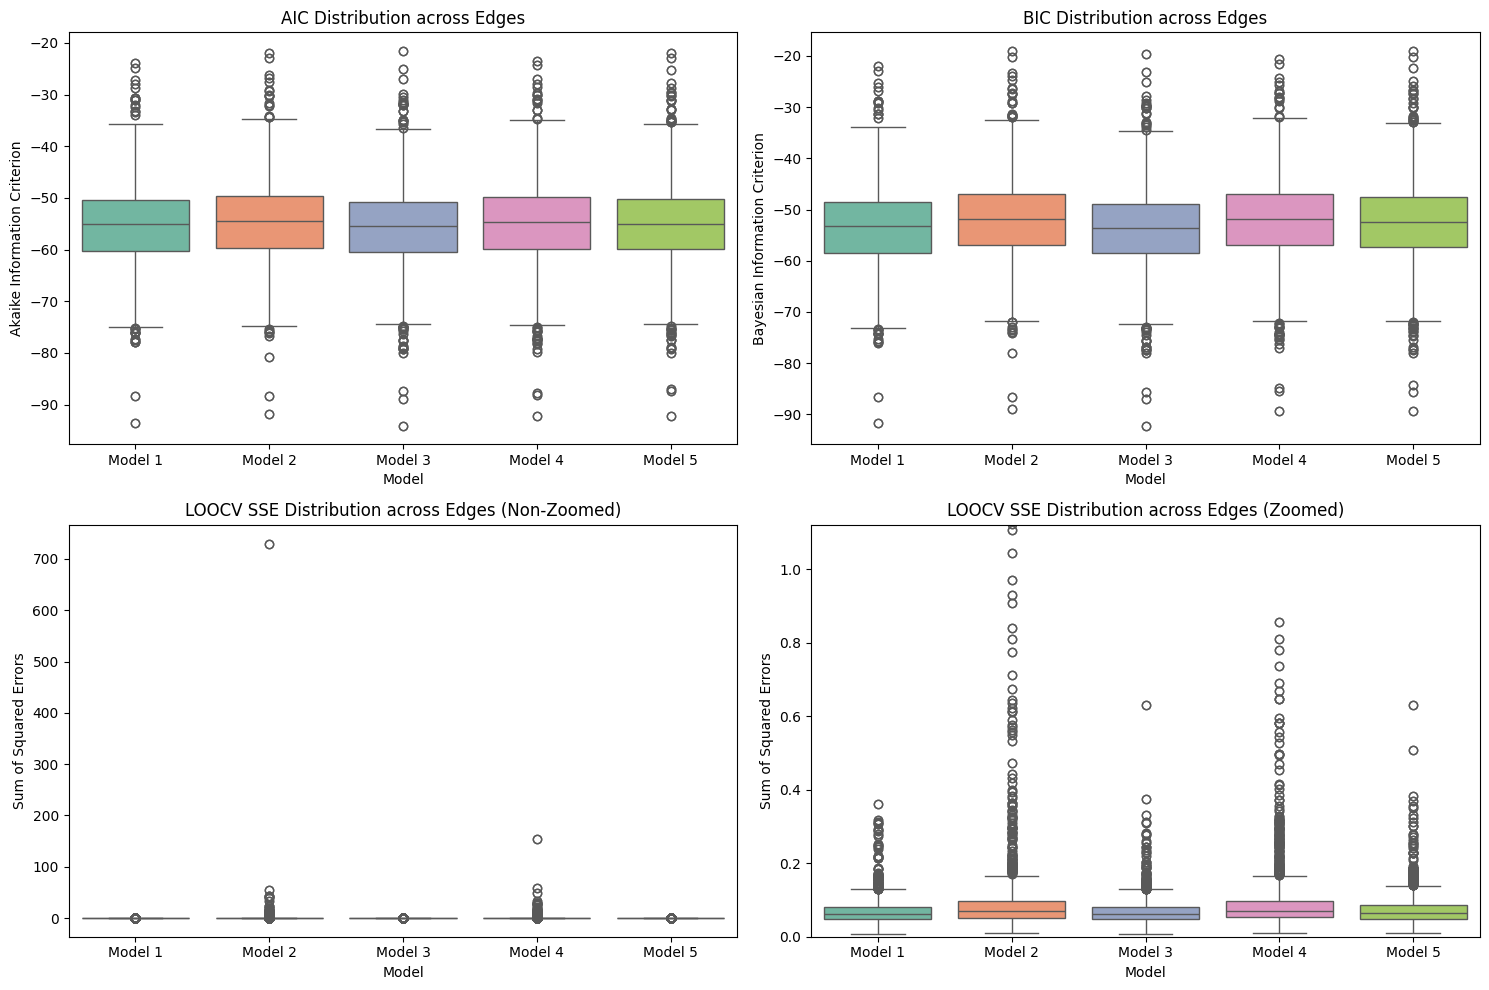

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data lists for AIC, BIC, and SSE
data = []

model_names = ['Model 1', 'Model 2', 'Model 3', 'Model 4', 'Model 5']
res_dicts = [model1_results, model2_results, model3_results, model4_results, model5_results]
sse_dicts = [sse_model1, sse_model2, sse_model3, sse_model4, sse_model5]

for idx, m_name in enumerate(model_names):
    current_res = res_dicts[idx]
    current_sse = sse_dicts[idx]

    # Get common keys (edges) present in both results and SSE for consistency
    common_keys = set(current_res.keys()) & set(current_sse.keys())

    for key in common_keys:
        data.append({
            'Model': m_name,
            'AIC': current_res[key].aic,
            'BIC': current_res[key].bic,
            'SSE': current_sse[key]
        })

# Create DataFrame
comparison_df = pd.DataFrame(data)

# Plotting: Create a 2x2 grid for the plots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# AIC Box Plot (Top-Left)
sns.boxplot(data=comparison_df, x='Model', y='AIC', ax=axes[0, 0], palette='Set2', hue='Model', legend=False)
axes[0, 0].set_title('AIC Distribution across Edges')
axes[0, 0].set_ylabel('Akaike Information Criterion')

# BIC Box Plot (Top-Right)
sns.boxplot(data=comparison_df, x='Model', y='BIC', ax=axes[0, 1], palette='Set2', hue='Model', legend=False)
axes[0, 1].set_title('BIC Distribution across Edges')
axes[0, 1].set_ylabel('Bayesian Information Criterion')

# Non-zoomed SSE Box Plot (Bottom-Left)
sns.boxplot(data=comparison_df, x='Model', y='SSE', ax=axes[1, 0], palette='Set2', hue='Model', legend=False)
axes[1, 0].set_title('LOOCV SSE Distribution across Edges (Non-Zoomed)')
axes[1, 0].set_ylabel('Sum of Squared Errors')

# Zoomed SSE Box Plot (Bottom-Right)
sns.boxplot(data=comparison_df, x='Model', y='SSE', ax=axes[1, 1], palette='Set2', hue='Model', legend=False)
axes[1, 1].set_title('LOOCV SSE Distribution across Edges (Zoomed)')
axes[1, 1].set_ylabel('Sum of Squared Errors')

# Set y-axis limit for the zoomed SSE plot
upper_limit_sse = comparison_df['SSE'].quantile(0.99)
axes[1, 1].set_ylim(0, upper_limit_sse)

plt.tight_layout()
plt.show()

Based on the plots, seems that model 3 is the one that performs the best

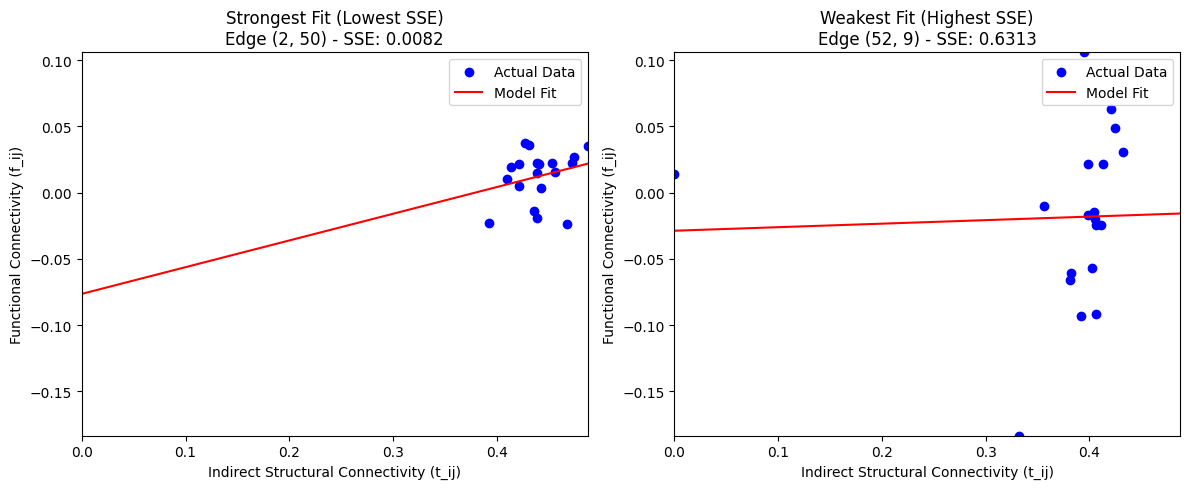

In [38]:
# Get common keys present in both results and SSE for consistency
common_keys = set(model3_results.keys()) & set(sse_model3.keys())

# Filter sse_model3 to only include common keys
filtered_sse_model3 = {k: sse_model3[k] for k in common_keys}

if not filtered_sse_model3:
    print("No common edges found between Model 3 results and SSE. Cannot plot best/worst fit.")
else:
    best_edge = min(filtered_sse_model3, key=filtered_sse_model3.get)
    worst_edge = max(filtered_sse_model3, key=filtered_sse_model3.get)

    edges_to_plot = {
        "Strongest Fit (Lowest SSE)": best_edge,
        "Weakest Fit (Highest SSE)": worst_edge
    }

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    all_t_ij_vals = []
    all_f_ij_vals = []

    for title, edge in edges_to_plot.items():
        i, j = edge
        t_ij_temp = np.array([T_matrices[s][i, j] for s in subjects])
        f_ij_temp = np.array([functional[s][i, j] for s in subjects])
        all_t_ij_vals.extend(t_ij_temp)
        all_f_ij_vals.extend(f_ij_temp)

    # Determine global min/max for consistent scaling
    global_t_ij_min = min(all_t_ij_vals)
    global_t_ij_max = max(all_t_ij_vals)
    global_f_ij_min = min(all_f_ij_vals)
    global_f_ij_max = max(all_f_ij_vals)

    for ax_idx, (title, edge) in enumerate(edges_to_plot.items()):
        ax = axes[ax_idx]
        i, j = edge

        # Use t_ij because model uses the indirect edges
        t_ij = np.array([T_matrices[s][i, j] for s in subjects])
        f_ij = np.array([functional[s][i, j] for s in subjects])

        # Get model result for the current edge
        model_result = model3_results[edge]

        # For Model 3, it's fij = beta0 + beta1 * t_ij. params will have 2 elements.
        intercept = model_result.params[0]
        slope = model_result.params[1]

        # Scatter plot of the raw data
        ax.scatter(t_ij, f_ij, color='blue', label='Actual Data')

        # Plot the regression line
        # We use global min and max of t_ij to draw the line across the full range of the data
        x_vals = np.linspace(global_t_ij_min, global_t_ij_max, 100)
        y_vals = intercept + slope * x_vals
        ax.plot(x_vals, y_vals, color='red', label='Model Fit')

        # Formatting the plot
        ax.set_title(f"{title}\nEdge ({i}, {j}) - SSE: {sse_model3[edge]:.4f}")
        ax.set_xlabel("Indirect Structural Connectivity (t_ij)")
        ax.set_ylabel("Functional Connectivity (f_ij)")
        ax.legend()

        # Set consistent x and y limits
        ax.set_xlim(global_t_ij_min, global_t_ij_max)
        ax.set_ylim(global_f_ij_min, global_f_ij_max)

    plt.tight_layout()
    plt.show()

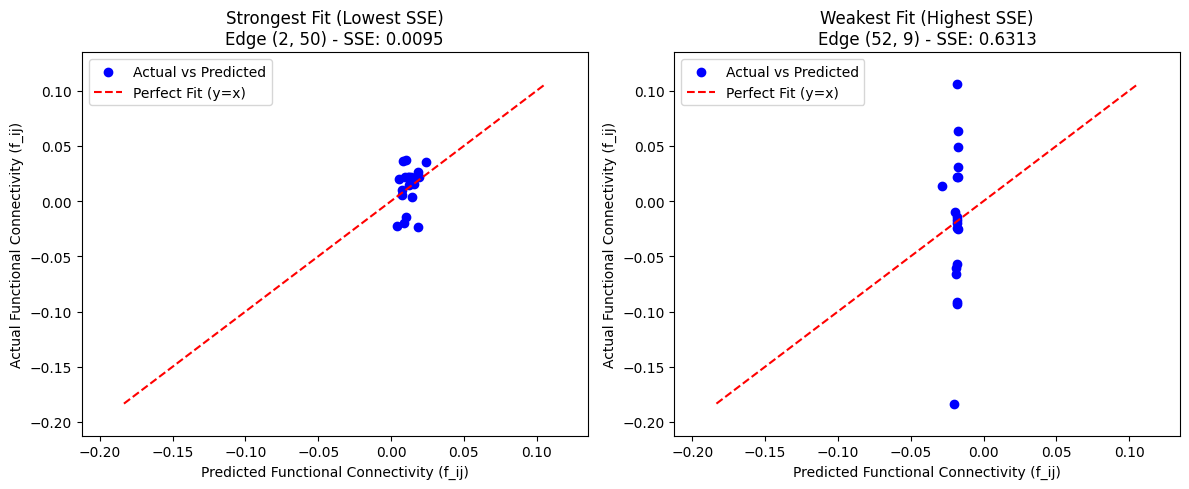

In [39]:
# Get common keys present in both results and SSE for consistency
common_keys_model5 = set(model5_results.keys()) & set(sse_model5.keys())

# Filter sse_model5 to only include common keys
filtered_sse_model5 = {k: sse_model5[k] for k in common_keys_model5}

if not filtered_sse_model5:
    print("No common edges found between Model 5 results and SSE. Cannot plot best/worst fit.")
else:
    best_edge_model5 = min(filtered_sse_model5, key=filtered_sse_model5.get)
    worst_edge_model5 = max(filtered_sse_model5, key=filtered_sse_model5.get)

    edges_to_plot_model5 = {
        "Strongest Fit (Lowest SSE)": best_edge_model5,
        "Weakest Fit (Highest SSE)": worst_edge_model5
    }

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    all_actual_f_ij_vals = []
    all_predicted_f_ij_vals = []

    for title, edge in edges_to_plot_model5.items():
        i, j = edge

        # Actual functional connectivity values
        f_ij_actual = np.array([functional[s][i, j] for s in subjects])

        # Prepare exogenous variables for prediction
        s_ij = np.array([structural[s][i, j] for s in subjects])
        t_ij = np.array([T_matrices[s][i, j] for s in subjects])
        X_pred = np.column_stack([s_ij, t_ij]) # Model 5 uses both s_ij and t_ij
        X_pred = sm.add_constant(X_pred) # Add constant term

        # Get model result for the current edge and predict
        model_result = model5_results[edge]
        predicted_f_ij = model_result.predict(X_pred)

        all_actual_f_ij_vals.extend(f_ij_actual)
        all_predicted_f_ij_vals.extend(predicted_f_ij)

    # Determine global min/max for consistent scaling
    global_min_val = min(min(all_actual_f_ij_vals), min(all_predicted_f_ij_vals))
    global_max_val = max(max(all_actual_f_ij_vals), max(all_predicted_f_ij_vals))

    # Add some padding to the limits
    padding = (global_max_val - global_min_val) * 0.1
    x_lim = (global_min_val - padding, global_max_val + padding)
    y_lim = (global_min_val - padding, global_max_val + padding)

    for ax_idx, (title, edge) in enumerate(edges_to_plot_model5.items()):
        ax = axes[ax_idx]
        i, j = edge

        f_ij_actual = np.array([functional[s][i, j] for s in subjects])

        s_ij = np.array([structural[s][i, j] for s in subjects])
        t_ij = np.array([T_matrices[s][i, j] for s in subjects])
        X_pred = np.column_stack([s_ij, t_ij])
        X_pred = sm.add_constant(X_pred)

        model_result = model5_results[edge]
        predicted_f_ij = model_result.predict(X_pred)

        # Scatter plot of actual vs predicted data
        ax.scatter(predicted_f_ij, f_ij_actual, color='blue', label='Actual vs Predicted')

        # Plot the perfect fit line (y=x)
        ax.plot([global_min_val, global_max_val], [global_min_val, global_max_val], color='red', linestyle='--', label='Perfect Fit (y=x)')

        # Formatting the plot
        ax.set_title(f"{title}\nEdge ({i}, {j}) - SSE: {sse_model5[edge]:.4f}")
        ax.set_xlabel("Predicted Functional Connectivity (f_ij)")
        ax.set_ylabel("Actual Functional Connectivity (f_ij)")
        ax.legend()

        # Set consistent x and y limits
        ax.set_xlim(x_lim)
        ax.set_ylim(y_lim)

    plt.tight_layout()
    plt.show()

## Global Models: Single Set of Coefficients for All Edges

In [40]:
def collect_global_data(functional_data, structural_data, indirect_structural_data, subject_list,
                        include_s, include_t, include_s2, include_t2):
    all_y, all_X = [], []
    for i in range(num_regions):
        for j in range(num_regions):
            if i == j:
                continue
            exog_vars = get_features(structural_data, indirect_structural_data, subject_list,
                                     i, j, include_s, include_t, include_s2, include_t2)
            if not exog_vars or np.all(np.column_stack(exog_vars) == 0):
                continue
            f_ij = np.array([functional_data[s][i, j] for s in subject_list])
            all_y.extend(f_ij)
            all_X.extend(np.column_stack(exog_vars))
    return np.array(all_y), sm.add_constant(np.array(all_X))

model_configs = {
    'Model 1': {'include_s': True,  'include_t': False, 'include_s2': False, 'include_t2': False},
    'Model 2': {'include_s': True,  'include_t': False, 'include_s2': True,  'include_t2': False},
    'Model 3': {'include_s': False, 'include_t': True,  'include_s2': False, 'include_t2': False},
    'Model 4': {'include_s': False, 'include_t': True,  'include_s2': False, 'include_t2': True},
    'Model 5': {'include_s': True,  'include_t': True,  'include_s2': False, 'include_t2': False},
}

global_models    = {}
n_obs_per_model  = {}

for name, config in model_configs.items():
    y_g, X_g = collect_global_data(functional, structural, T_matrices, subjects, **config)
    n_obs_per_model[name] = len(y_g)
    global_models[name]   = sm.OLS(y_g, X_g).fit()
    n_edges = len(y_g) // len(subjects)
    print(f"{name}: n_obs={len(y_g)}, n_edges={n_edges}, AIC={global_models[name].aic:.2f}, BIC={global_models[name].bic:.2f}, R²={global_models[name].rsquared:.4f}")


Model 1: n_obs=57836, n_edges=3044, AIC=-131781.52, BIC=-131763.59, R²=0.0087
Model 2: n_obs=57836, n_edges=3044, AIC=-134317.80, BIC=-134290.90, R²=0.0512
Model 3: n_obs=86298, n_edges=4542, AIC=-209195.62, BIC=-209176.89, R²=0.0017
Model 4: n_obs=86298, n_edges=4542, AIC=-209266.02, BIC=-209237.93, R²=0.0025
Model 5: n_obs=86298, n_edges=4542, AIC=-210603.59, BIC=-210575.49, R²=0.0179


In [41]:
def perform_global_loocv(config_dict):
    total_sse = 0
    for idx in range(len(subjects)):
        train_subjects = [s for i, s in enumerate(subjects) if i != idx]
        test_subject   = subjects[idx]
        y_train, X_train = collect_global_data(functional, structural, T_matrices, train_subjects, **config_dict)
        model_train      = sm.OLS(y_train, X_train).fit()
        y_test, X_test   = collect_global_data(functional, structural, T_matrices, [test_subject], **config_dict)
        total_sse       += np.sum((y_test - model_train.predict(X_test))**2)
    return total_sse

global_sse = {}
for name, config in model_configs.items():
    global_sse[name] = perform_global_loocv(config)
    print(f"{name} Global LOOCV SSE: {global_sse[name]:.4f}")


Model 1 Global LOOCV SSE: 236.9971
Model 2 Global LOOCV SSE: 223.1567
Model 3 Global LOOCV SSE: 428.0666
Model 4 Global LOOCV SSE: 427.6781
Model 5 Global LOOCV SSE: 421.0287


Common edges across all per-edge models: 3044

── Per-Edge Model Selection (mean over common edges) ──
  Model  Mean AIC  Mean BIC  Mean LOOCV SSE
Model 1  -55.2482  -53.3593          0.0689
Model 2  -54.5851  -51.8740          0.9401
Model 3  -55.2960  -53.4072          0.0684
Model 4  -54.5354  -51.7021          0.3169
Model 5  -54.5188  -51.6855          0.0748

── Global Model Selection ──
  Model  Mean LOOCV SSE
Model 1          0.0779
Model 2          0.0733
Model 3          0.0942
Model 4          0.0942
Model 5          0.0927


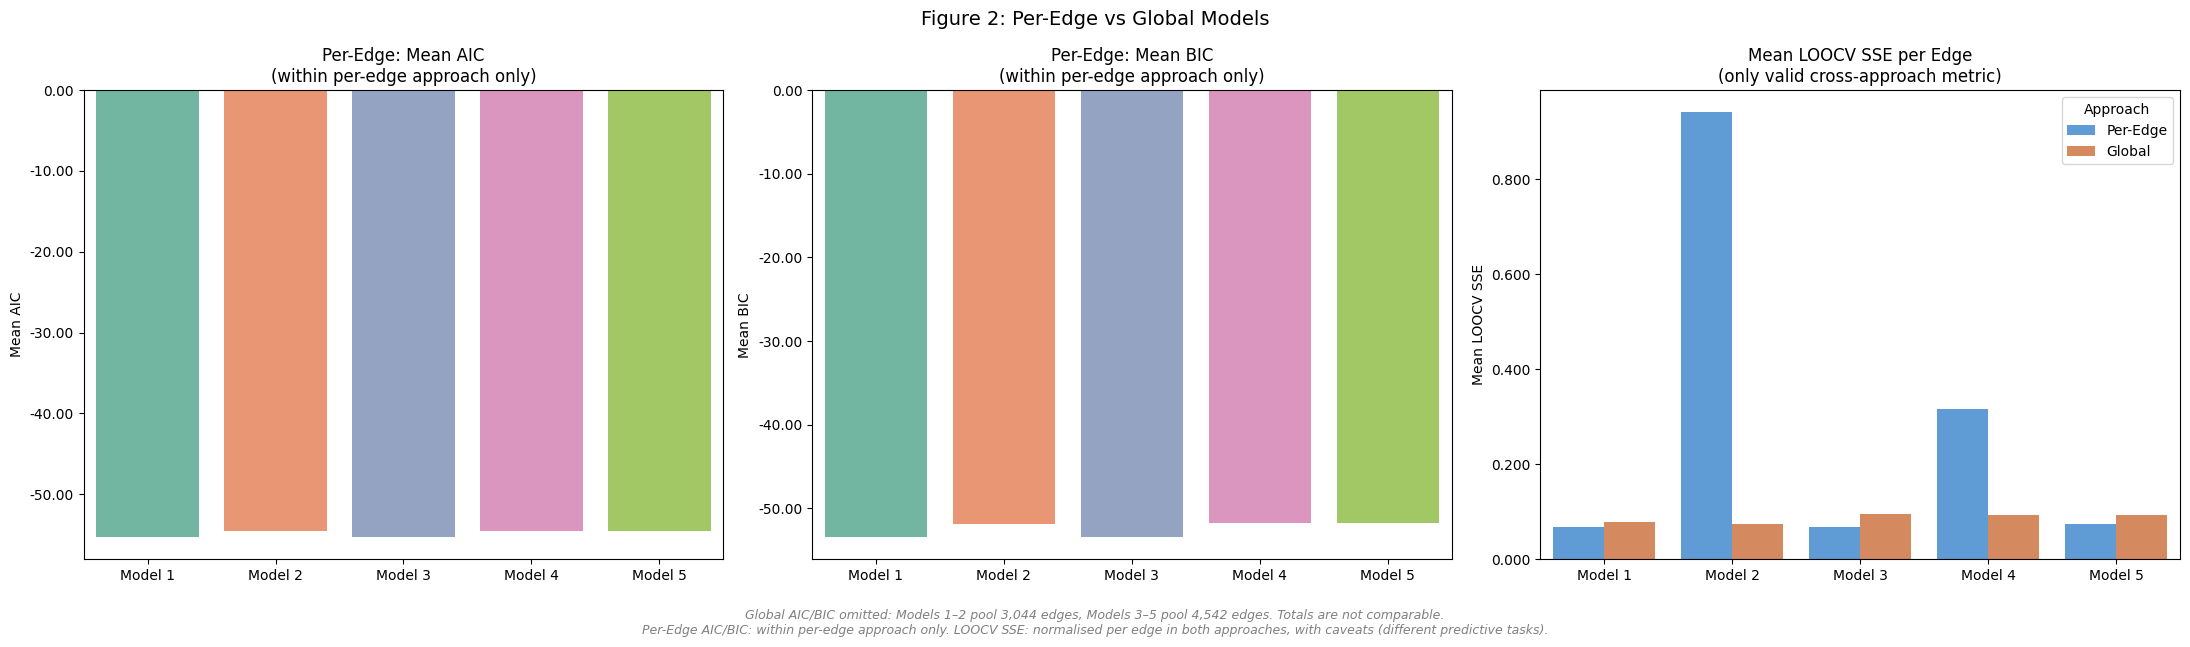

In [42]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

model_names = ['Model 1', 'Model 2', 'Model 3', 'Model 4', 'Model 5']
res_dicts   = [model1_results, model2_results, model3_results, model4_results, model5_results]
sse_dicts   = [sse_model1,     sse_model2,     sse_model3,     sse_model4,     sse_model5]

common_keys_all = set(res_dicts[0].keys())
for rd in res_dicts[1:]:
    common_keys_all &= set(rd.keys())

for name, sd in zip(model_names, sse_dicts):
    missing = common_keys_all - set(sd.keys())
    assert len(missing) == 0, f"{name} SSE dict is missing {len(missing)} edges from the common edge set"

print(f"Common edges across all per-edge models: {len(common_keys_all)}")

per_edge_rows = []
for name, rd, sd in zip(model_names, res_dicts, sse_dicts):
    per_edge_rows.append({
        'Model':          name,
        'Mean AIC':       np.mean([rd[k].aic for k in common_keys_all]),
        'Mean BIC':       np.mean([rd[k].bic for k in common_keys_all]),
        'Mean LOOCV SSE': np.mean([sd[k]     for k in common_keys_all]),
    })
per_edge_df = pd.DataFrame(per_edge_rows)

n_edges_per_model = {name: n_obs_per_model[name] // len(subjects) for name in model_names}

global_rows = []
for name in model_names:
    m       = global_models[name]
    n_edges = n_edges_per_model[name]
    global_rows.append({
        'Model':          name,
        'Mean LOOCV SSE': global_sse[name] / n_edges,
    })
global_df = pd.DataFrame(global_rows)

print("\n── Per-Edge Model Selection (mean over common edges) ──")
print(per_edge_df.to_string(index=False, float_format=lambda x: f"{x:,.4f}"))
print("\n── Global Model Selection ──")
print(global_df.to_string(index=False, float_format=lambda x: f"{x:,.4f}"))

per_edge_df['Approach'] = 'Per-Edge'
global_df['Approach']   = 'Global'
loocv_compare_df = pd.concat([
    per_edge_df[['Model', 'Mean LOOCV SSE', 'Approach']],
    global_df  [['Model', 'Mean LOOCV SSE', 'Approach']]
], ignore_index=True)

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle('Figure 2: Per-Edge vs Global Models', fontsize=14)

sns.barplot(data=per_edge_df, x='Model', y='Mean AIC',
            ax=axes[0], palette='Set2', hue='Model', legend=False)
axes[0].set_title('Per-Edge: Mean AIC\n(within per-edge approach only)')
axes[0].set_xlabel('')
axes[0].yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

sns.barplot(data=per_edge_df, x='Model', y='Mean BIC',
            ax=axes[1], palette='Set2', hue='Model', legend=False)
axes[1].set_title('Per-Edge: Mean BIC\n(within per-edge approach only)')
axes[1].set_xlabel('')
axes[1].yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

sns.barplot(data=loocv_compare_df, x='Model', y='Mean LOOCV SSE',
            hue='Approach', ax=axes[2],
            palette={'Per-Edge': '#4C9BE8', 'Global': '#E8834C'})
axes[2].set_title('Mean LOOCV SSE per Edge\n(only valid cross-approach metric)')
axes[2].set_xlabel('')
axes[2].legend(title='Approach')
axes[2].yaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))

note = (
    "Global AIC/BIC omitted: Models 1–2 pool 3,044 edges, Models 3–5 pool 4,542 edges. Totals are not comparable.\n"
    "Per-Edge AIC/BIC: within per-edge approach only. LOOCV SSE: normalised per edge in both approaches, with caveats (different predictive tasks)."
)
fig.text(0.5, -0.06, note, ha='center', fontsize=9, style='italic', color='gray')

plt.tight_layout()
plt.show()
